# Agent ReAct (LangGraph — `StateGraph` à la main)

- Aucun module du dossier `src/` — tout est dans ce notebook.
- **ReAct** : boucle modèle ⇄ outil (`agent` → `tools` → `agent` …).
- **Outils** : `@tool` personnalisés (`tree_of_thoughts`, `web_search`, …).
- **LLM** : `ChatMistralAI` et/ou `ChatOpenAI` selon ce que tu invoques.
Prérequis : clés API dans l'environnement (`MISTRAL_API_KEY`, `OPENAI_API_KEY`, selon les appels).


## Schéma du flux (pédagogie)

**Idée :** un nœud **agent** (le LLM) et un nœud **tools** (exécute tes `@tool`) en boucle, jusqu’à ce que le LLM réponde **sans** appeler d’outil.

### Mermaid (affichage si ton viewer le supporte : GitHub, Cursor, extensions Jupyter)

```mermaid
flowchart LR
  subgraph Entrée
    U["👤 Toi\nHumanMessage"]
  end
  subgraph Graphe
    A["🧠 agent\nLLM + bind_tools"]
    T["🔧 tools\nToolNode"]
    E(("🏁 FIN"))
  end
  U --> A
  A -->|"besoin d'un outil\ntool_calls"| T
  T -->|"résultat → messages"| A
  A -->|"plus d'outil\nréponse texte"| E
```

### ASCII (lisible partout)

```
     Toi
       │
       ▼
   ┌────────┐   oui (tool_calls)   ┌────────┐
   │ agent  │ ───────────────────► │ tools  │
   │ (LLM)  │ ◄─────────────────── │ @tool  │
   └────────┘   retour texte       └────────┘
       │
       │ non → FIN → réponse finale
       ▼
```

**`tree_of_thoughts`** : un des outils que **tools** peut appeler ; il reçoit une chaîne `topic` et renvoie une chaîne (texte des pistes ou stub selon ton code).


In [ ]:
# LangGraph — le moteur du graphe (nœuds, edges, State)
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
# LangChain Mistral — le connecteur entre LangGraph et l'API Mistral
from langchain_mistralai import ChatMistralAI
from langchain_openai import ChatOpenAI

# LangChain Core — pour créer des outils avec @tool
from langchain_core.tools import tool

# Python standard — pour typer le State
from typing import Annotated
from typing_extensions import TypedDict

In [12]:
# langchain(ou langgraph) trouve ta clé tout seul
llm_mistral = ChatMistralAI(model="mistral-medium-latest", temperature=0.7)
llm_openai = ChatOpenAI(model="gpt-5.4-mini", temperature=0.7)

In [6]:
class State(TypedDict):
    messages: Annotated[list[dict], add_messages]

print(State)


<class '__main__.State'>


In [ ]:
@tool
def tree_of_thoughts(topic: str) -> str:
    """ You have to developp the topic by exploring tree of thoughts about the topic. generate about 10 differents thoughts about the topic. """
    return f"I will generate 10 differents thoughts about the topic {topic}"

@tool
def best_three_thoughts(enhance_reasonging : str ) -> str:
    """ You have to select the best 3 thoughts from the tree of thoughts and summerize it in a structured way"""
    return f"here is my enhancement of the 3 best thoughts {enhance_reasonging}"

@tool
def critical_thinking(critical_thinking : str) -> str:
    """ you are a pro critical thinker, and you have to criticize the enhancement and search on web to see if it's true or not. """
    return f"here is my critical thinking {critical_thinking}"

@tool
def web_search(web_search : str) -> str:
    """ You have to search the web when you want to check if the enhancement is true or not. """
    return f"here is my web search {web_search}"

tools = [tree_of_thoughts, best_three_thoughts, critical_thinking, web_search]

llm_with_tools = llm_mistral.bind_tools(tools)

In [9]:
# noeud1 je définie le premier noeud , pour montrer les outils au llm
def agent_node(state: State) -> dict:
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}
# on ajoute un noeud qui est fait par langraph qui lit le dernier msg de state[messages] \\ 
# prend l'attribut tool_calls lit son argument et sa value et mets à jour le state
tool_node = ToolNode(tools)

In [10]:
# déclarer le routeur ReAct
def should_continue(state: State) -> str:
    last_message = state["messages"][-1]  # récupérer le dernier message
    if last_message.tool_calls:           # si le LLM veut un outil
        return "tools"
    else:
        return END                        # sinon terminer

# instancier le graphe avec ton State
graph_builder = StateGraph(State)

# enregistrer les nœuds dans le graphe
graph_builder.add_node("agent", agent_node)
graph_builder.add_node("tools", tool_node)

# définir le point d'entrée
graph_builder.set_entry_point("agent")

# brancher l'edge conditionnel depuis agent
graph_builder.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})

# brancher l'edge fixe — la boucle ReAct
graph_builder.add_edge("tools", "agent")

# compiler le graphe → crée l'objet exécutable
app = graph_builder.compile()

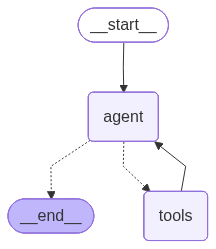

In [11]:
app

## Graphe directionnel + boucle critique → revise (max 6 fois)

- Ordre **imposé** : `ingest` → `critique` → (`revise` → `critique`) … → `final_answer` → fin.
- **`memory_summary`** : **résumé progressif** (mis à jour après ingest, puis après chaque critique et chaque revise) pour garder une mémoire compacte dans le state.
- **`critique_loop_count`** : plafond **6** sorties du nœud `critique`.

*(Indépendant du graphe ReAct `agent`/`tools` au-dessus — `PipelineState`.)*


In [14]:
# --- Pipeline + résumé progressif (mémoire compacte dans le state) ---
from langchain_core.messages import AIMessage, HumanMessage

MAX_CRITIQUE_ROUNDS = 6
SUMMARY_MAX_WORDS = 280  # budget verbal du résumé cumulatif (indicatif pour le prompt)


class PipelineState(TypedDict):
    messages: Annotated[list, add_messages]
    critique_loop_count: int
    draft: str
    memory_summary: str


def update_progressive_summary(
    previous: str,
    phase: str,
    new_text: str,
) -> str:
    """Fusionne le résumé précédent avec la nouvelle info (une passe LLM = mémoire progressive)."""
    chunk = (new_text or "")[:8000]
    prompt = (
        "Tu maintiens un résumé cumulatif court du déroulé (mémoire de travail pour les étapes suivantes).\n\n"
        f"Résumé précédent :\n{previous or '(vide)'}\n\n"
        f"Nouvelle information — étape « {phase} » :\n{chunk}\n\n"
        f"Fusionne en un seul texte continu en français, "
        f"en conservant faits, décisions et tensions utiles ; vise au plus ~{SUMMARY_MAX_WORDS} mots. "
        "Pas de titre ni « Résumé : »."
    )
    response = llm_mistral.invoke([HumanMessage(content=prompt)])
    return (getattr(response, "content", None) or str(response)).strip()


def ingest_node(state: PipelineState) -> dict:
    msgs = state.get("messages") or []
    last_human = ""
    for m in reversed(msgs):
        if isinstance(m, HumanMessage):
            last_human = (m.content or "").strip()
            break
        if isinstance(m, dict) and m.get("role") == "user":
            last_human = (m.get("content") or "").strip()
            break
    draft = last_human or ""
    seed_summary = update_progressive_summary("", "ingest / sujet", f"Sujet posé par l'utilisateur :\n{draft}")
    return {"draft": draft, "critique_loop_count": 0, "memory_summary": seed_summary}


def critique_node(state: PipelineState) -> dict:
    draft = state.get("draft", "")
    prev_sum = state.get("memory_summary", "")
    prompt = (
        "Tu es un relecteur critique. Analyse le brouillon, liste les faiblesses, "
        "puis termine OBLIGATOIREMENT par une ligne sur sa propre ligne exactement : "
        "soit `VERDICT: OK` (suffisant) soit `VERDICT: REVISE` (à améliorer).\n\n"
        f"Brouillon :\n{draft}"
    )
    response = llm_mistral.invoke([HumanMessage(content=prompt)])
    msg = response if isinstance(response, AIMessage) else AIMessage(content=getattr(response, "content", str(response)))
    critique_body = getattr(msg, "content", "") or ""
    new_count = state.get("critique_loop_count", 0) + 1
    new_summary = update_progressive_summary(
        prev_sum,
        f"critique (tour {new_count})",
        critique_body,
    )
    return {
        "messages": [msg],
        "critique_loop_count": new_count,
        "memory_summary": new_summary,
    }


def route_after_critique(state: PipelineState) -> str:
    if state.get("critique_loop_count", 0) >= MAX_CRITIQUE_ROUNDS:
        return "final_answer"
    last = state["messages"][-1]
    body = (getattr(last, "content", None) or "").upper()
    if "VERDICT: OK" in body:
        return "final_answer"
    return "revise"


def revise_node(state: PipelineState) -> dict:
    critique_text = state["messages"][-1].content if state["messages"] else ""
    prev_sum = state.get("memory_summary", "")
    prompt = (
        "Réécris et améliore le brouillon en tenant compte de la critique. "
        "Réponds uniquement avec le nouveau texte du brouillon, sans préambule.\n\n"
        f"Brouillon actuel :\n{state.get('draft', '')}\n\n"
        f"Critique :\n{critique_text}"
    )
    response = llm_mistral.invoke([HumanMessage(content=prompt)])
    new_draft = getattr(response, "content", None) or str(response)
    new_draft = new_draft.strip()
    ack = AIMessage(content=f"[revise] Brouillon mis à jour (longueur {len(new_draft)} car.).")
    new_summary = update_progressive_summary(
        prev_sum,
        "revise / nouveau brouillon",
        f"Nouveau brouillon après revise :\n{new_draft[:4000]}",
    )
    return {"draft": new_draft, "messages": [ack], "memory_summary": new_summary}


def final_answer_node(state: PipelineState) -> dict:
    summary = state.get("memory_summary", "")
    draft = state.get("draft", "")
    prompt = (
        "Synthétise une réponse finale claire en français pour l'utilisateur.\n"
        "Tenez compte du résumé progressif du raisonnement ET du dernier brouillon.\n\n"
        f"--- Résumé progressif ---\n{summary}\n\n"
        f"--- Dernier brouillon ---\n{draft}"
    )
    response = llm_mistral.invoke([HumanMessage(content=prompt)])
    msg = response if isinstance(response, AIMessage) else AIMessage(content=getattr(response, "content", str(response)))
    return {"messages": [msg]}


pipeline_builder = StateGraph(PipelineState)
pipeline_builder.add_node("ingest", ingest_node)
pipeline_builder.add_node("critique", critique_node)
pipeline_builder.add_node("revise", revise_node)
pipeline_builder.add_node("final_answer", final_answer_node)

pipeline_builder.set_entry_point("ingest")
pipeline_builder.add_edge("ingest", "critique")
pipeline_builder.add_conditional_edges(
    "critique",
    route_after_critique,
    {"final_answer": "final_answer", "revise": "revise"},
)
pipeline_builder.add_edge("revise", "critique")
pipeline_builder.add_edge("final_answer", END)

pipeline_app = pipeline_builder.compile()

print(
    "Pipeline : ingest (résumé initial) → critique ⇄ revise (résumé mis à jour chaque fois) → final_answer"
)


Pipeline compilé : ingest → critique ⇄ revise (max 6 tours critique) → final_answer


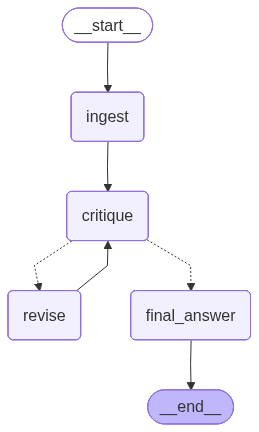

In [15]:
pipeline_app

In [16]:
# --- Essai : entrée utilisateur + affichage du résumé progressif final ---
demo = pipeline_app.invoke(
    {
        "messages": [
            HumanMessage(
                content="L'IA va remplacer tous les profs d'ici 2026. Argumente brièvement pour ou contre."
            )
        ],
        "critique_loop_count": 0,
        "draft": "",
        "memory_summary": "",
    }
)

print("critique_loop_count final :", demo.get("critique_loop_count"))
print("\n--- memory_summary (résumé progressif) ---\n", demo.get("memory_summary", "")[:2000], "\n…")
print("\ndraft final (extrait) :", (demo.get("draft") or "")[:400], "…")
print("\n--- Messages ---")
for m in demo.get("messages", []):
    name = type(m).__name__
    c = getattr(m, "content", "") or ""
    print(f"\n[{name}] {c[:600]}{'…' if len(c) > 600 else ''}")


critique_loop_count final : 6
draft final (extrait) : **D’ici 2030, l’IA transformera 20 % des tâches enseignantes – mais pour mieux recentrer les professeurs sur l’humain**

---

### **1. Automatiser l’administratif pour libérer du temps pédagogique**
L’intelligence artificielle commence déjà à soulager les enseignants des tâches chronophages, leur permettant de se consacrer à l’essentiel : l’accompagnement des élèves. Aux **États-Unis**, l’outil *G …

--- Messages ---

[HumanMessage] L'IA va remplacer tous les profs d'ici 2026. Argumente brièvement pour ou contre.

[AIMessage] ### **Analyse critique du brouillon**

#### **Faiblesses majeures :**
1. **Thèse trop radicale et non nuancée** :
   - L’affirmation *"L'IA va remplacer **tous** les profs d'ici 2026"* est **exagérée et invérifiable**.
     - *Problèmes* :
       - "Tous" est un absolu difficile à défendre (même les profs de maternelle ? les enseignants en zones rurales sans infrastructure ?).
       - 2026 est un délai **irréa